# 3. Demand Analysis

This notebook analyzes demand over time to identify trends, patterns, seasonality, and demand variability.

The objective is to understand how demand changes over time and determine which features can be used for demand forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/sales_data.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [2]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (76000, 16)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Data types:
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object


## 1. Time-Based Demand Analysis

Demand forecasting is a time-dependent problem. Therefore, we first convert the Date column into a proper datetime format and examine how demand changes over time.

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of unique dates:", df["Date"].nunique())

Date range:
2022-01-01 00:00:00 to 2024-01-30 00:00:00

Number of unique dates: 760


## 2. Daily Demand Trend

We aggregate demand by date to understand the overall demand pattern over time.

In [4]:
daily_demand = (
    df.groupby("Date")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
    .reset_index()
)

daily_demand.head()

,Date,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
0,2022-01-01,10060,100.60,15,229
1,2022-01-02,10814,108.14,4,234
2,2022-01-03,11317,113.17,22,207
3,2022-01-04,11469,114.69,28,235
4,2022-01-05,11724,117.24,37,307


In [5]:
print("Daily demand records:", len(daily_demand))

print("\nAverage daily demand:")
print(daily_demand["Total_Demand"].mean())

print("\nMinimum daily demand:")
print(daily_demand["Total_Demand"].min())

print("\nMaximum daily demand:")
print(daily_demand["Total_Demand"].max())

Daily demand records: 760

Average daily demand:
10431.715789473685

Minimum daily demand:
5859

Maximum daily demand:
14093


### Daily Demand Trend Visualization

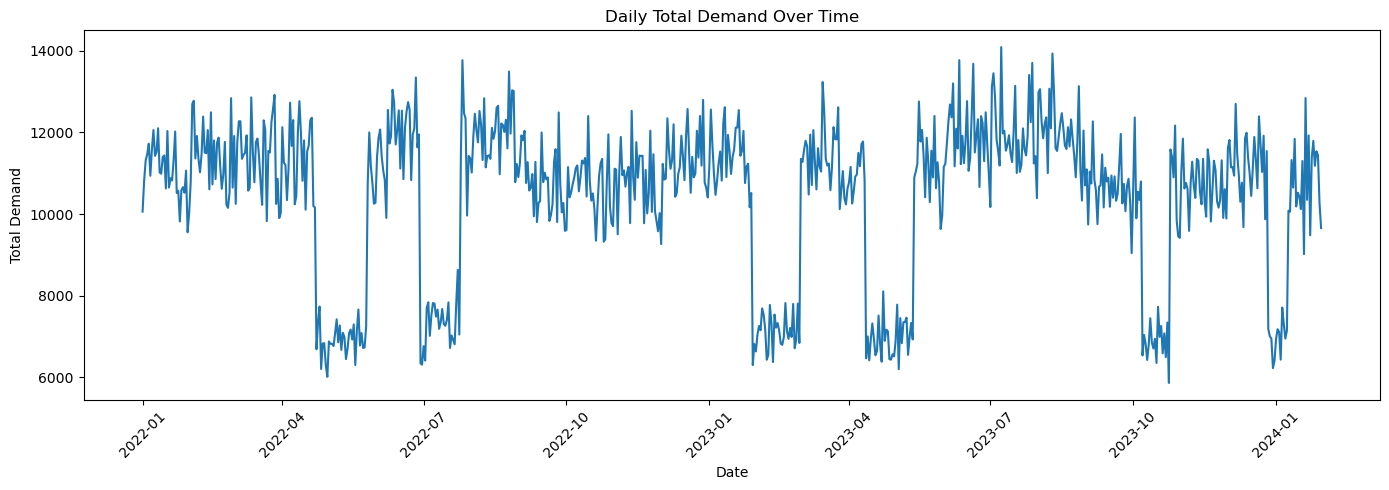

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Total_Demand"]
)

plt.title("Daily Total Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Rolling Demand Analysis

Rolling averages are used to smooth short-term fluctuations and identify the underlying demand trend over time.

In [7]:
daily_demand["7_Day_Moving_Average"] = (
    daily_demand["Total_Demand"]
    .rolling(window=7)
    .mean()
)

daily_demand["30_Day_Moving_Average"] = (
    daily_demand["Total_Demand"]
    .rolling(window=30)
    .mean()
)

daily_demand.head(35)

,Date,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand,7_Day_Moving_Average,30_Day_Moving_Average
0,2022-01-01,10060,100.60,15,229,NaN,NaN
1,2022-01-02,10814,108.14,4,234,NaN,NaN
2,2022-01-03,11317,113.17,22,207,NaN,NaN
3,2022-01-04,11469,114.69,28,235,NaN,NaN
4,2022-01-05,11724,117.24,37,307,NaN,NaN
5,2022-01-06,10938,109.38,31,198,NaN,NaN
6,2022-01-07,11584,115.84,33,259,11129.428571,NaN
7,2022-01-08,12060,120.60,36,279,11415.142857,NaN
8,2022-01-09,11427,114.27,34,263,11502.714286,NaN
9,2022-01-10,11523,115.23,21,271,11532.142857,NaN


### Moving Average Visualization

The 7-day and 30-day moving averages help distinguish short-term demand fluctuations from the longer-term demand trend.

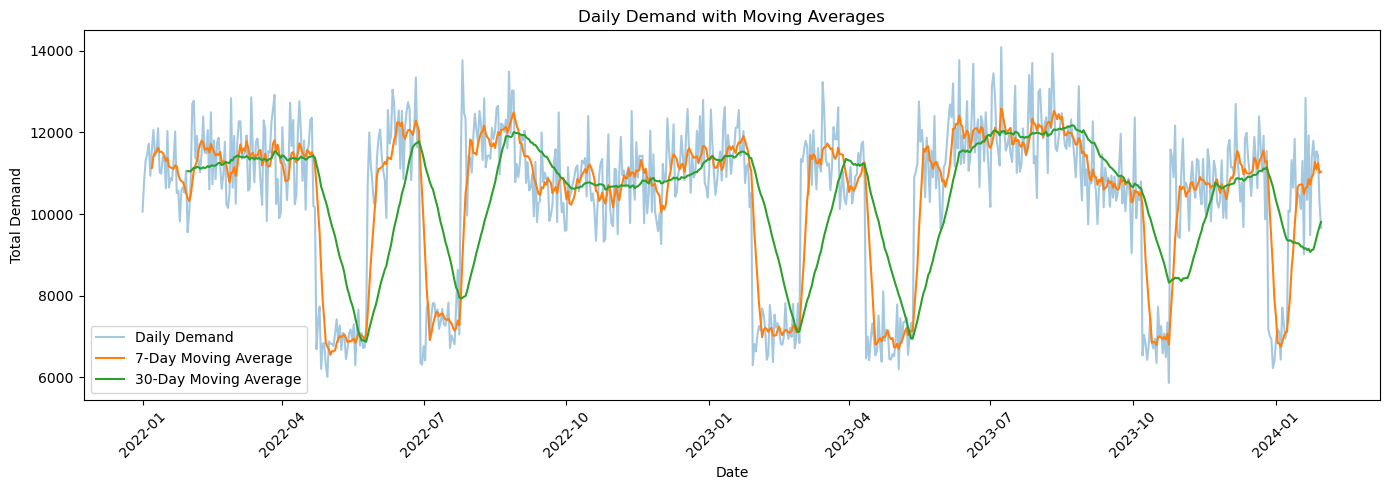

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Total_Demand"],
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["7_Day_Moving_Average"],
    label="7-Day Moving Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["30_Day_Moving_Average"],
    label="30-Day Moving Average"
)

plt.title("Daily Demand with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
print("Average 7-day moving demand:")
print(daily_demand["7_Day_Moving_Average"].mean())

print("\nAverage 30-day moving demand:")
print(daily_demand["30_Day_Moving_Average"].mean())

print("\nHighest 7-day moving demand:")
print(daily_demand["7_Day_Moving_Average"].max())

print("\nHighest 30-day moving demand:")
print(daily_demand["30_Day_Moving_Average"].max())

Average 7-day moving demand:
10429.02936718454

Average 30-day moving demand:
10413.099270405837

Highest 7-day moving demand:
12587.857142857143

Highest 30-day moving demand:
12176.566666666668


### Interpretation

The daily demand series shows substantial short-term variation. 
The 7-day moving average smooths daily fluctuations and provides a clearer view of short-term demand behavior, while the 30-day moving average highlights the longer-term demand trend.

These patterns are important for demand forecasting because future demand is influenced by both short-term fluctuations and longer-term trends.

## 5. Demand Analysis by Category

We analyze total demand across product categories to identify which categories contribute most to overall demand.

In [10]:
category_demand = (
    df.groupby("Category")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
    .sort_values("Total_Demand", ascending=False)
)

category_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Category,,,,
Groceries,3677684,120.976447,4,430
Clothing,1369456,112.619737,4,330
Furniture,1006590,73.581140,4,214
Toys,985338,92.606955,4,361
Electronics,889036,97.482018,4,339


### Category Demand Visualization

The following visualization compares total demand across product categories.

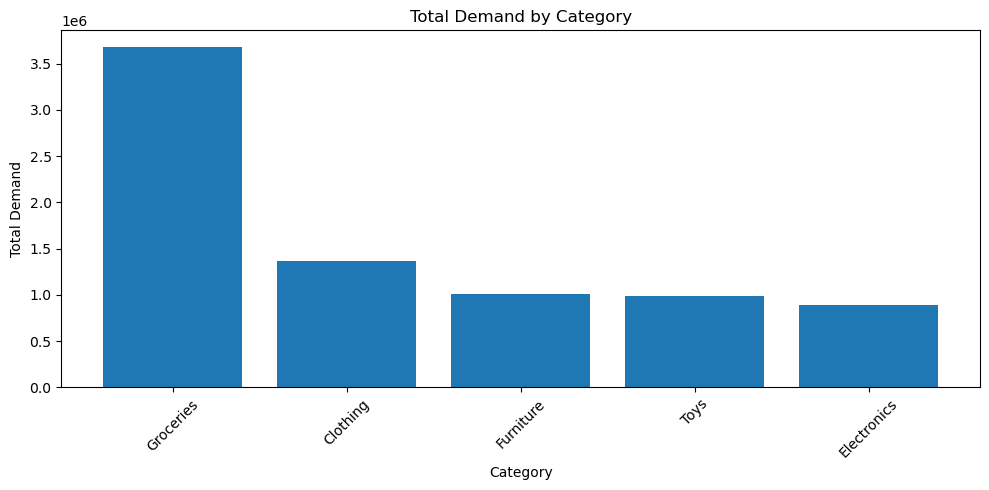

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_demand.index,
    category_demand["Total_Demand"]
)

plt.title("Total Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Demand Analysis by Region

We analyze demand across different regions to identify regional differences in product demand.

In [12]:
region_demand = (
    df.groupby("Region")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
    .sort_values("Total_Demand", ascending=False)
)

region_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Region,,,,
North,3154658,103.771645,4,430
South,1625471,106.938882,4,351
East,1618324,106.468684,4,361
West,1529651,100.634934,4,370


### Regional Demand Visualization

The following visualization compares total demand across regions.

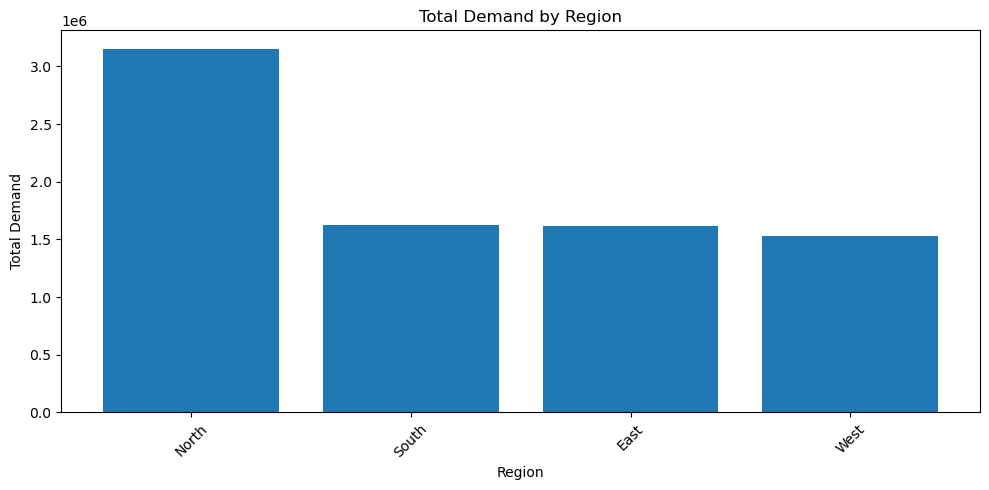

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    region_demand.index,
    region_demand["Total_Demand"]
)

plt.title("Total Demand by Region")
plt.xlabel("Region")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Demand Drivers Analysis

Demand can be influenced by several factors such as price, discounts, promotions, weather conditions, competitor pricing, inventory levels, and seasonality.

We analyze the relationship between these variables and demand to identify potentially useful predictors for demand forecasting.

### 7.1 Demand vs Price

We examine the relationship between product price and demand to determine whether changes in price are associated with changes in demand.

In [16]:
price_demand_corr = df[["Price", "Demand"]].corr()

price_demand_corr

,Price,Demand
Price,1.000000,-0.023461
Demand,-0.023461,1.000000


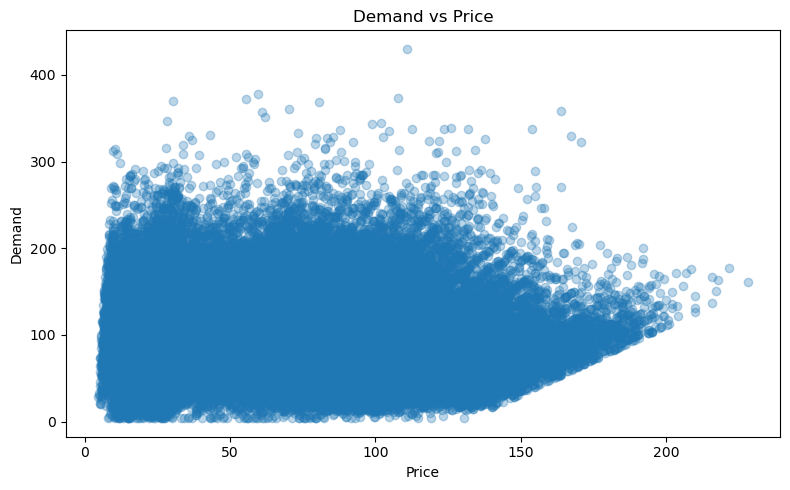

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Price"],
    df["Demand"],
    alpha=0.3
)

plt.title("Demand vs Price")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 7.2 Demand vs Discount

We examine the relationship between discount percentage and demand to determine whether discounts are associated with changes in customer demand.

In [18]:
discount_demand_corr = df[["Discount", "Demand"]].corr()

discount_demand_corr

,Discount,Demand
Discount,1.000000,0.224723
Demand,0.224723,1.000000


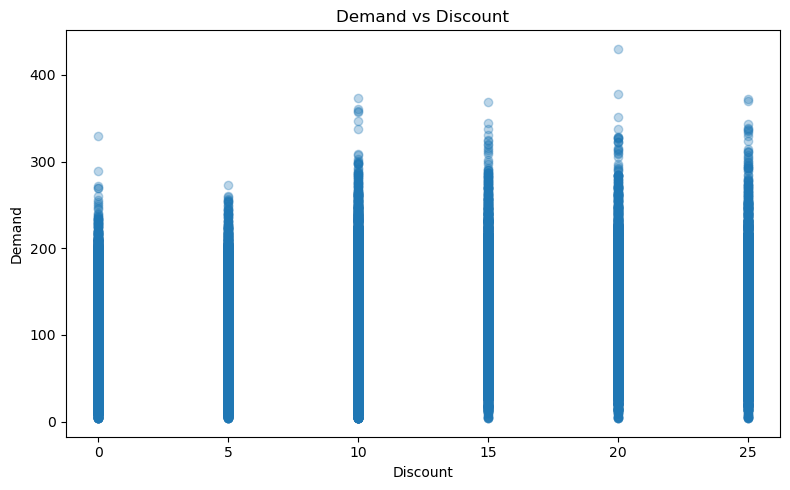

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["Demand"],
    alpha=0.3
)

plt.title("Demand vs Discount")
plt.xlabel("Discount")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 7.3 Demand vs Promotion

We examine whether promotional activity is associated with changes in product demand.

In [20]:
df["Promotion"].value_counts()


Promotion
0    51000
1    25000
Name: count, dtype: int64

In [21]:
promotion_demand = (
    df.groupby("Promotion")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

promotion_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Promotion,,,,
0,4846369,95.026843,4,330
1,3081735,123.269400,4,430


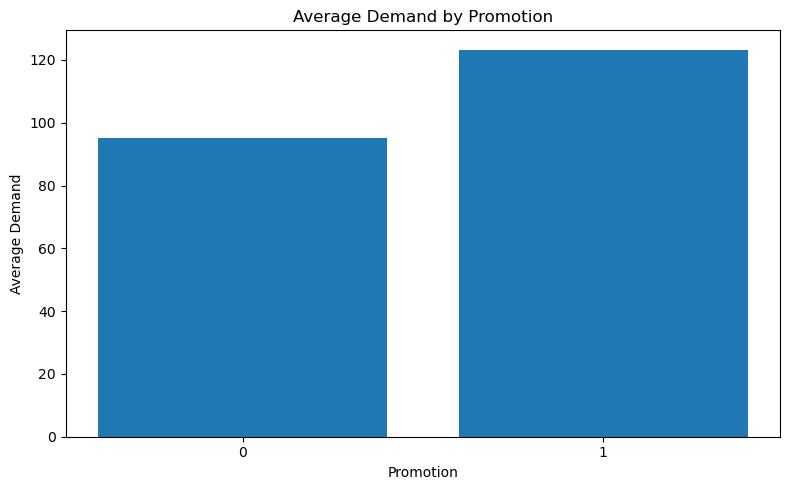

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    promotion_demand.index.astype(str),
    promotion_demand["Average_Demand"]
)

plt.title("Average Demand by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 7.4 Demand vs Inventory

We examine the relationship between inventory levels and demand to determine whether inventory availability may influence observed demand.

In [26]:
inventory_demand_corr = df[["Inventory Level", "Demand"]].corr()

inventory_demand_corr

,Inventory Level,Demand
Inventory Level,1.000000,0.126618
Demand,0.126618,1.000000


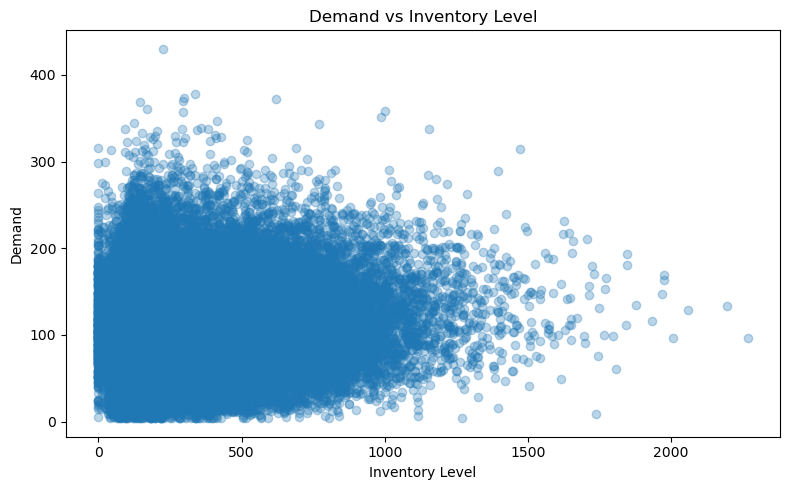

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Inventory Level"],
    df["Demand"],
    alpha=0.3
)

plt.title("Demand vs Inventory Level")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### 7.5 Demand vs Competitor Pricing

We examine the relationship between competitor pricing and demand to determine whether competitor prices may influence customer demand.

In [28]:
competitor_demand_corr = df[["Competitor Pricing", "Demand"]].corr()

competitor_demand_corr

,Competitor Pricing,Demand
Competitor Pricing,1.000000,-0.023036
Demand,-0.023036,1.000000


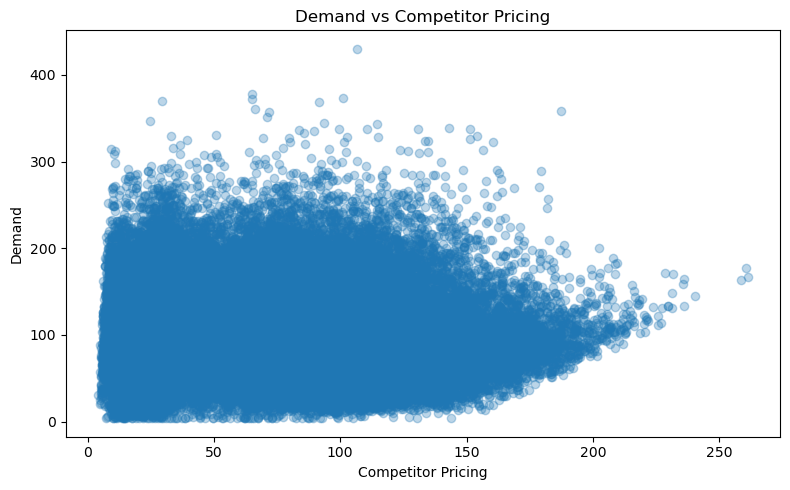

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Competitor Pricing"],
    df["Demand"],
    alpha=0.3
)

plt.title("Demand vs Competitor Pricing")
plt.xlabel("Competitor Pricing")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Interpretation

The correlation between competitor pricing and demand is approximately -0.023, indicating a very weak negative relationship.

This suggests that changes in competitor pricing do not have a strong linear relationship with observed demand in this dataset.

Therefore, competitor pricing may have limited predictive value when considered independently, although it may still contribute to demand forecasting when combined with other variables.

### 7.6 Demand vs Weather Condition

We examine whether different weather conditions are associated with changes in product demand.

In [36]:
df["Seasonality"].value_counts()

Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

In [37]:
seasonality_demand = (
    df.groupby("Seasonality")["Demand"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Minimum_Demand="min",
          Maximum_Demand="max"
      )
)

seasonality_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Seasonality,,,,
Autumn,1882298,103.422967,4,327
Spring,1797737,97.703098,4,361
Summer,2076539,112.855380,4,430
Winter,2171530,103.406190,4,339


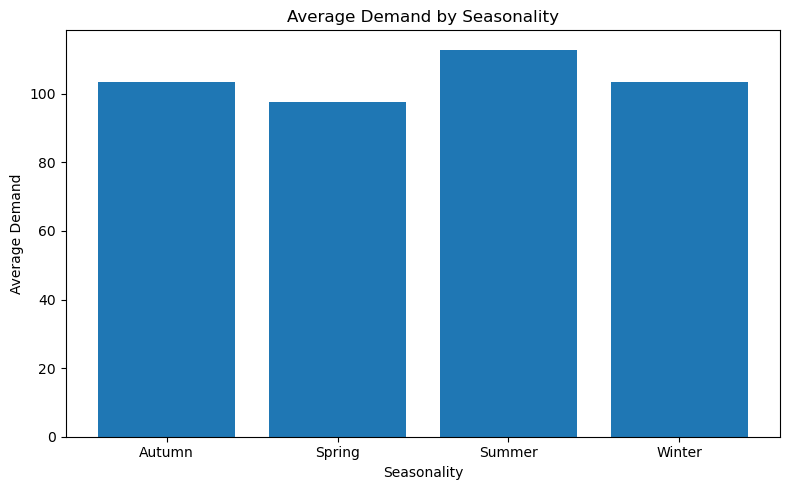

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonality_demand.index,
    seasonality_demand["Average_Demand"]
)

plt.title("Average Demand by Seasonality")
plt.xlabel("Seasonality")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

Demand varies across different seasonal categories. This indicates that seasonality may be an important factor for demand forecasting.

The seasonal category with the highest average demand represents a period of relatively stronger demand, while the category with the lowest average demand represents weaker demand.

Therefore, Seasonality should be considered as a potential feature in the forecasting model.

## 7.7 Demand vs Weather Condition

We examine whether different weather conditions are associated with changes in product demand.

In [39]:
df["Weather Condition"].value_counts()

Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

In [40]:
weather_demand = (
    df.groupby("Weather Condition")["Demand"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Minimum_Demand="min",
          Maximum_Demand="max"
      )
)

weather_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Weather Condition,,,,
Cloudy,2567643,105.404064,4,373
Rainy,1664368,95.106743,4,378
Snowy,1049551,94.045789,4,260
Sunny,2646542,115.167189,4,430


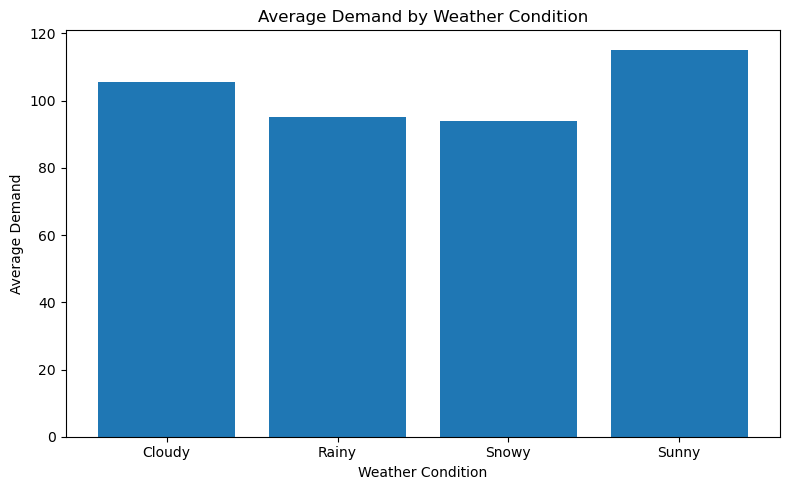

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_demand.index,
    weather_demand["Average_Demand"]
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

Demand varies across different weather conditions.

Sunny weather has the highest average demand at approximately 115.17 units,
while Snowy weather has the lowest average demand at approximately 94.05 units.

Cloudy weather has an average demand of approximately 105.40 units,
while Rainy weather has an average demand of approximately 95.11 units.

This indicates that weather conditions may have an association with product demand.
Therefore, Weather Condition should be considered as a potential feature
in the demand forecasting model.

## 7.7 Demand vs Epidemic

We examine whether epidemic conditions are associated with changes in product demand.

In [42]:
df["Epidemic"].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64

In [43]:
epidemic_demand = (
    df.groupby("Epidemic")["Demand"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Minimum_Demand="min",
          Maximum_Demand="max"
      )
)

epidemic_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Epidemic,,,,
0,6861690,112.856743,4,430
1,1066414,70.158816,4,279


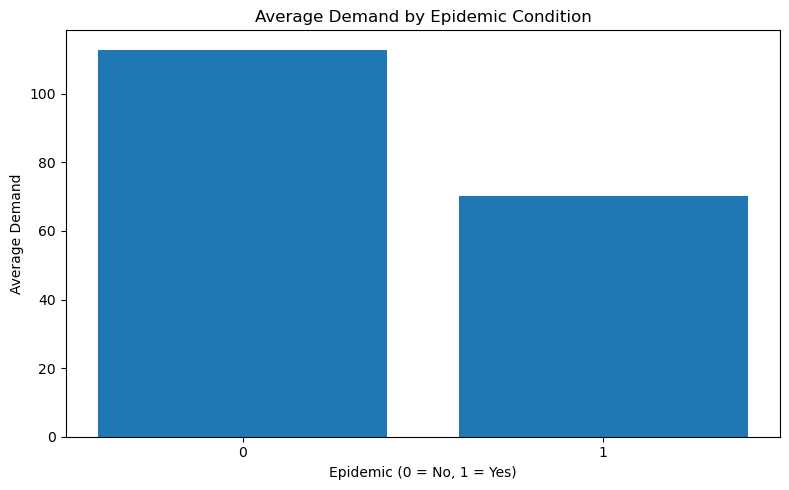

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    epidemic_demand.index.astype(str),
    epidemic_demand["Average_Demand"]
)

plt.title("Average Demand by Epidemic Condition")
plt.xlabel("Epidemic (0 = No, 1 = Yes)")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

Demand differs substantially between epidemic and non-epidemic conditions.

When there is no epidemic (Epidemic = 0), the average demand is approximately
112.86 units. During epidemic conditions (Epidemic = 1), the average demand
decreases to approximately 70.16 units.

This indicates that epidemic conditions are strongly associated with lower
observed demand in the dataset. Therefore, Epidemic should be considered as
an important feature in the demand forecasting model.

# 8. Feature Engineering

Feature engineering is the process of transforming existing data into useful input variables for a machine learning model.

For demand forecasting, the raw dataset contains several variables that may influence demand. We will create additional features from the existing data, especially from the Date column, and later create historical demand features such as lag and rolling values.

The objective is to provide the forecasting model with meaningful information about time, seasonality, historical demand, pricing, weather, and other relevant factors.

### 8.1 Date/Time Feature Engineering

The `Date` column contains temporal information that may influence product demand.
Since demand can vary depending on the day, month, season, or day of the week, we extract
useful time-based features from the date.

The following features are created:

- Year
- Month
- Day
- Day of Week
- Week of Year
- Quarter
- Weekend indicator

These features allow the demand forecasting model to learn temporal patterns in product demand.

In [48]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,DayOfWeek,Quarter
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,5,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,5,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,5,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,5,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,5,1


In [49]:
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df[["Date", "Year", "Month", "Day", "DayOfWeek", "WeekOfYear", "Quarter"]].head()

,Date,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter
0,2022-01-01,2022,1,1,5,52,1
1,2022-01-01,2022,1,1,5,52,1
2,2022-01-01,2022,1,1,5,52,1
3,2022-01-01,2022,1,1,5,52,1
4,2022-01-01,2022,1,1,5,52,1


In [50]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df[["Date", "DayOfWeek", "IsWeekend"]].head(10)

,Date,DayOfWeek,IsWeekend
0,2022-01-01,5,1
1,2022-01-01,5,1
2,2022-01-01,5,1
3,2022-01-01,5,1
4,2022-01-01,5,1
5,2022-01-01,5,1
6,2022-01-01,5,1
7,2022-01-01,5,1
8,2022-01-01,5,1
9,2022-01-01,5,1


In [51]:
df[[
    "Date",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "IsWeekend"
]].head(10)

,Date,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter,IsWeekend
0,2022-01-01,2022,1,1,5,52,1,1
1,2022-01-01,2022,1,1,5,52,1,1
2,2022-01-01,2022,1,1,5,52,1,1
3,2022-01-01,2022,1,1,5,52,1,1
4,2022-01-01,2022,1,1,5,52,1,1
5,2022-01-01,2022,1,1,5,52,1,1
6,2022-01-01,2022,1,1,5,52,1,1
7,2022-01-01,2022,1,1,5,52,1,1
8,2022-01-01,2022,1,1,5,52,1,1
9,2022-01-01,2022,1,1,5,52,1,1


In [52]:
df[[
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "IsWeekend"
]].dtypes

Year          int32
Month         int32
Day           int32
DayOfWeek     int32
WeekOfYear    int64
Quarter       int32
IsWeekend     int64
dtype: object

In [53]:
print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())
print("Number of unique dates:", df["Date"].nunique())

Minimum Date: 2022-01-01 00:00:00
Maximum Date: 2024-01-30 00:00:00
Number of unique dates: 760


### Interpretation

The Date column was successfully decomposed into multiple time-based features including
Year, Month, Day, Day of Week, Week of Year, Quarter, and Weekend status.

These features capture different temporal patterns that may influence product demand.
For example, demand may differ between weekdays and weekends, while monthly and quarterly
features can help the model identify seasonal patterns.

The original Date column is retained because it is important for maintaining the chronological
order of observations during time-series forecasting and model evaluation.

Therefore, the engineered date/time features will be considered as candidate features for
the demand forecasting model.

## 8.2 Seasonal Feature Engineering

Demand can vary across different seasons because customer purchasing behavior may
change depending on the time of year.

The dataset already contains a `Seasonality` feature. We first examine its
distribution and its relationship with demand before deciding how it should be
used in the forecasting model.

In [54]:
df["Seasonality"].value_counts()

Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

In [55]:
seasonal_demand = (
    df.groupby("Seasonality")["Demand"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Minimum_Demand="min",
          Maximum_Demand="max"
      )
)

seasonal_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Seasonality,,,,
Autumn,1882298,103.422967,4,327
Spring,1797737,97.703098,4,361
Summer,2076539,112.855380,4,430
Winter,2171530,103.406190,4,339


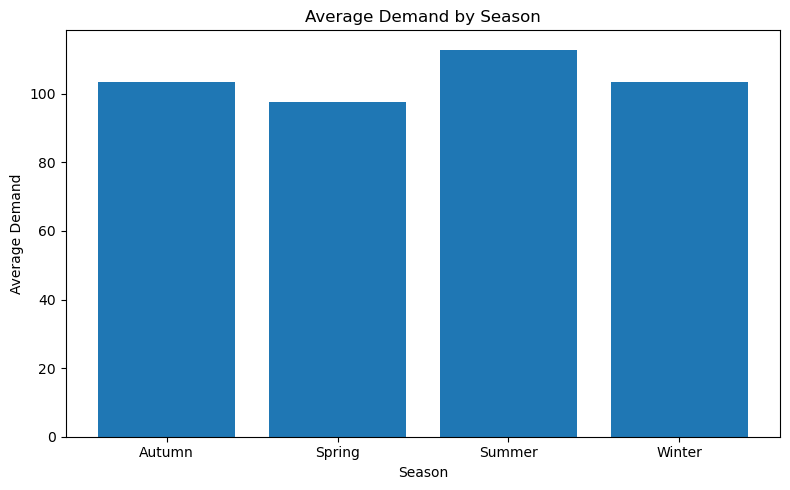

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonal_demand.index.astype(str),
    seasonal_demand["Average_Demand"]
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

Average demand varies across the four seasons.

Summer has the highest average demand at approximately 112.86 units, while Spring has the lowest average demand at approximately 97.70 units. Autumn and Winter have similar average demand levels of approximately 103.42 units and 103.41 units respectively.

This indicates that seasonal conditions may influence product demand. Therefore, Seasonality should be retained as a potential feature for the demand forecasting model.

## 8.3 Categorical Feature Engineering

The dataset contains several categorical variables such as Store ID, Product ID, Category, Region, Weather Condition, Seasonality, and other descriptive attributes.

Machine learning models generally require categorical variables to be represented numerically. Therefore, we first examine the categorical columns and their number of unique values before deciding on an appropriate encoding strategy.

This helps avoid unnecessary or inappropriate encoding and ensures that the final forecasting model receives meaningful features.

In [57]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

print("\nNumber of Unique Values:")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()}")

Categorical Columns:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

Number of Unique Values:
Store ID: 5
Product ID: 20
Category: 5
Region: 4
Weather Condition: 4
Seasonality: 4


### 8.3.1 Demand vs Category

We examine the relationship between product category and demand by calculating the total, average, minimum, and maximum demand for each category.

This helps determine whether product category provides useful information for demand forecasting.

In [58]:
category_demand = (
    df.groupby("Category")["Demand"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Minimum_Demand="min",
          Maximum_Demand="max"
      )
)

category_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Category,,,,
Clothing,1369456,112.619737,4,330
Electronics,889036,97.482018,4,339
Furniture,1006590,73.581140,4,214
Groceries,3677684,120.976447,4,430
Toys,985338,92.606955,4,361


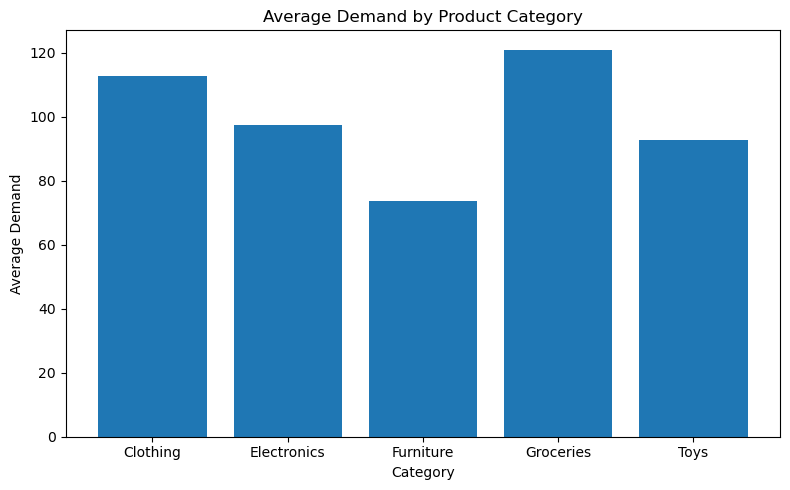

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_demand.index.astype(str),
    category_demand["Average_Demand"]
)

plt.title("Average Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

The average demand varies noticeably across product categories.

- **Groceries** has the highest average demand at approximately **120.98 units**.
- **Clothing** follows with an average demand of approximately **112.62 units**.
- **Electronics** has an average demand of approximately **97.42 units**.
- **Toys** has an average demand of approximately **92.61 units**.
- **Furniture** has the lowest average demand at approximately **73.58 units**.

The differences in average demand indicate that **Category is a useful feature for demand forecasting**, as different product categories exhibit different demand levels.

## 8.3.2 Demand vs Region

In [60]:
region_demand = (
    df.groupby("Region")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

region_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Region,,,,
East,1618324,106.468684,4,361
North,3154658,103.771645,4,430
South,1625471,106.938882,4,351
West,1529651,100.634934,4,370


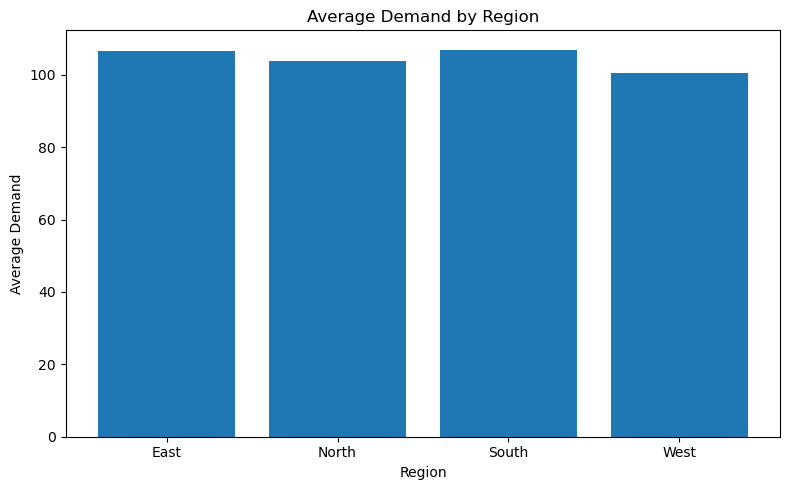

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_demand.index.astype(str),
    region_demand["Average_Demand"]
)

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Interpretation

The average demand shows some variation across regions.

- **South** has the highest average demand at approximately **106.94 units**.
- **East** follows closely with approximately **106.47 units**.
- **North** has an average demand of approximately **103.77 units**.
- **West** has the lowest average demand at approximately **100.63 units**.

Although the differences between regions are relatively small compared with the differences between product categories, the variation suggests that **Region may provide useful information for demand forecasting**.

Therefore, Region will be retained as a candidate categorical feature for the forecasting model.

## 8.3.3 Demand vs Weather Condition

In [62]:
weather_demand = (
    df.groupby("Weather Condition")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

weather_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Weather Condition,,,,
Cloudy,2567643,105.404064,4,373
Rainy,1664368,95.106743,4,378
Snowy,1049551,94.045789,4,260
Sunny,2646542,115.167189,4,430


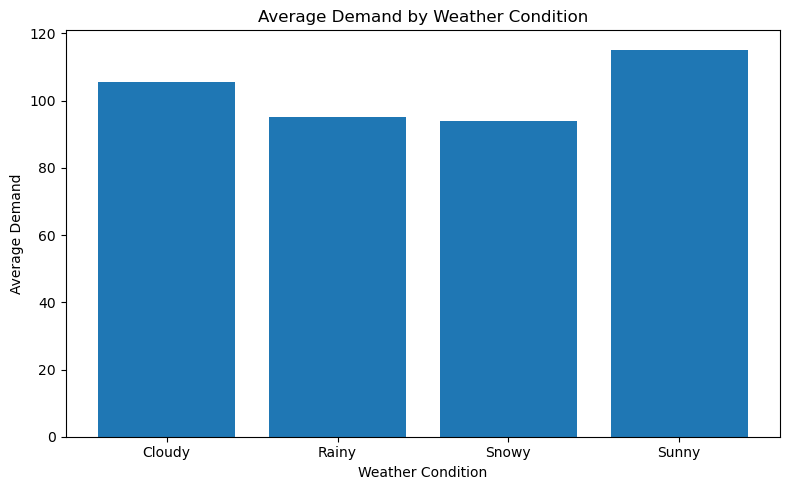

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_demand.index.astype(str),
    weather_demand["Average_Demand"]
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 8.3.4 Demand vs Seasonality

We examine the relationship between seasonality and demand by calculating the total, average, minimum, and maximum demand for each season.

This helps determine whether Seasonality provides useful information for demand forecasting.

In [64]:
seasonality_demand = (
    df.groupby("Seasonality")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

seasonality_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Seasonality,,,,
Autumn,1882298,103.422967,4,327
Spring,1797737,97.703098,4,361
Summer,2076539,112.855380,4,430
Winter,2171530,103.406190,4,339


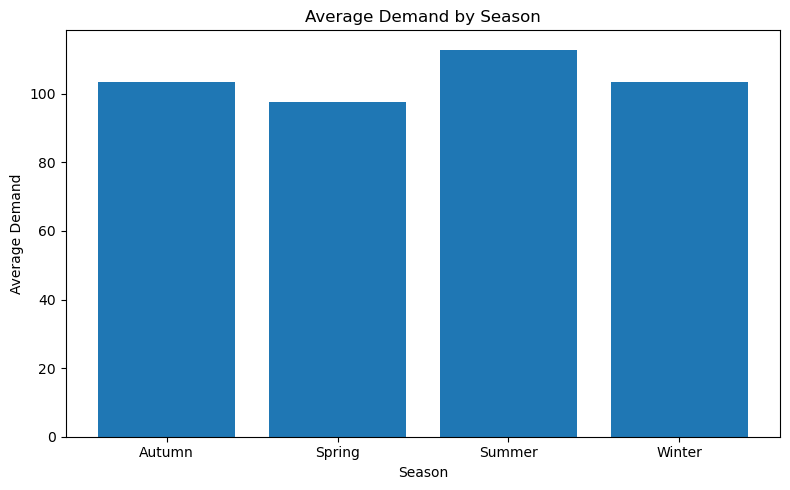

In [65]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonality_demand.index.astype(str),
    seasonality_demand["Average_Demand"]
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 8.3.5 Demand vs Store ID

We examine the relationship between store and demand by calculating the total, average, minimum, and maximum demand for each store.

This helps determine whether Store ID provides useful information for demand forecasting.

In [66]:
store_demand = (
    df.groupby("Store ID")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

store_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Store ID,,,,
S001,1547573,101.814013,4,378
S002,1625471,106.938882,4,351
S003,1618324,106.468684,4,361
S004,1529651,100.634934,4,370
S005,1607085,105.729276,4,430


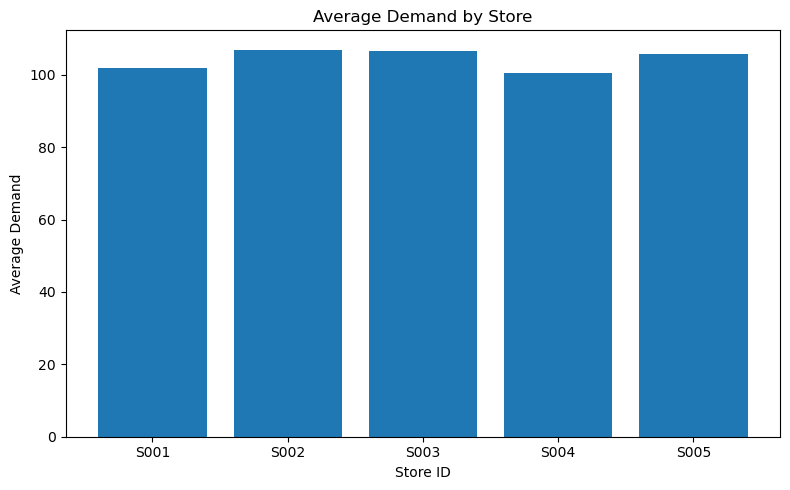

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    store_demand.index.astype(str),
    store_demand["Average_Demand"]
)

plt.title("Average Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 8.3.6 Demand vs Product ID

We examine the relationship between product and demand by calculating the total, average, minimum, and maximum demand for each product.

This helps determine whether Product ID provides useful information for demand forecasting.

In [68]:
product_demand = (
    df.groupby("Product ID")["Demand"]
    .agg(
        Total_Demand="sum",
        Average_Demand="mean",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

product_demand

,Total_Demand,Average_Demand,Minimum_Demand,Maximum_Demand
Product ID,,,,
P0001,416447,109.591316,4,291
P0002,425853,112.066579,4,370
P0003,395182,103.995263,4,324
P0004,438505,115.396053,4,351
P0005,408578,107.520526,4,347
P0006,409345,107.722368,4,373
P0007,437089,115.023421,4,331
P0008,396538,104.352105,4,430
P0009,450324,118.506316,4,338


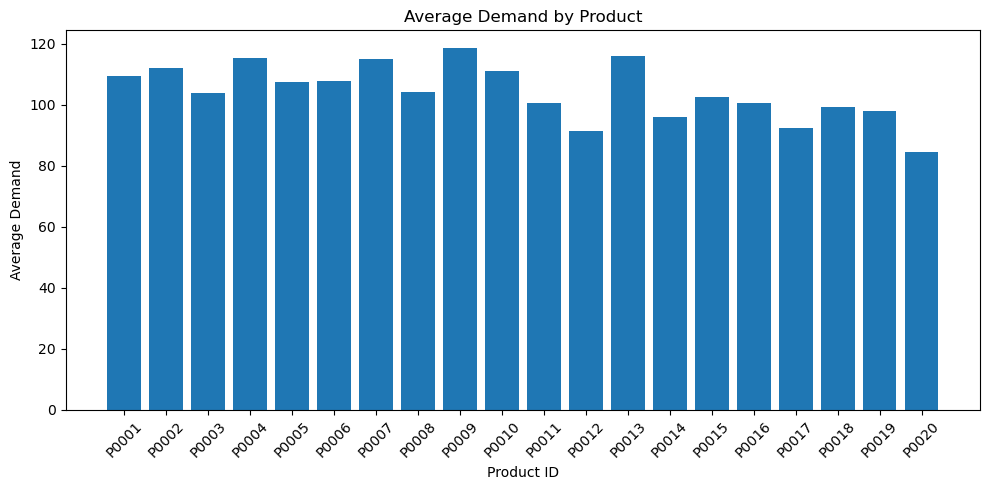

In [69]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_demand.index.astype(str),
    product_demand["Average_Demand"]
)

plt.title("Average Demand by Product")
plt.xlabel("Product ID")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()